In [1]:
%load_ext watermark


In [2]:
import os

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib.path import Path
from matplotlib import text as mtext
import pandas as pd
from teeplot import teeplot as tp

import pylib  # noqa: F401
from pyfonts import load_google_font


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-02-08T17:51:46.873241+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.16.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

pandas    : 1.4.4
pylib     : 0.0.0
matplotlib: 3.5.3
numpy     : 1.21.6
teeplot   : 1.4.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2026-02-04-complexity-drivers")
teeplot_subdir


'2026-02-04-complexity-drivers'

## Example Plot


In [5]:
while "breakable":
    try:
        font= load_google_font("Merriweather", weight = "extra-bold")
        slimfont = load_google_font("Merriweather")
        break
    except Exception as e:
        print(f"Could not load Merriweather font: {e}")
        pass
    try:
        from matplotlib.font_manager import FontProperties
        font = FontProperties(family='serif')
        break
    except Exception as e:
        print(f"Could not load serif font: {e}")
        pass

    font = None
    break

print(f"Using font: {font}")


Using font: sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:file=/home/runner/.cache/pyfontsloader/0fe0342e8335027701c745672894137bae8f39c7c90315ef9e4a24ea19cd5bff.ttf:size=10.0


In [6]:
# curved text adapted from https://stackoverflow.com/a/44521963


In [7]:
# --- 1. The CurvedText Class ---

class CurvedText(mtext.Text):
    """
    A text object that follows an arbitrary curve.
    """
    def __init__(self, x, y, text, axes, **kwargs):
        super(CurvedText, self).__init__(x[0],y[0],' ', **kwargs)

        axes.add_artist(self)

        self.__x = x
        self.__y = y
        self.__zorder = self.get_zorder()

        self.__Characters = []
        for c in text:
            if c == ' ':
                t = mtext.Text(0,0,'a')
                t.set_alpha(0.0)
            else:
                t = mtext.Text(0,0,c, **kwargs)

            t.set_ha('center')
            t.set_rotation(0)
            t.set_zorder(self.__zorder +1)

            self.__Characters.append((c,t))
            axes.add_artist(t)

    def set_zorder(self, zorder):
        super(CurvedText, self).set_zorder(zorder)
        self.__zorder = self.get_zorder()
        for c,t in self.__Characters:
            t.set_zorder(self.__zorder+1)

    def draw(self, renderer, *args, **kwargs):
        self.update_positions(renderer)

    def update_positions(self, renderer):
        xlim = self.axes.get_xlim()
        ylim = self.axes.get_ylim()
        figW, figH = self.axes.get_figure().get_size_inches()
        bbox = self.axes.get_position()
        w, h = bbox.width, bbox.height

        dx = xlim[1]-xlim[0] if xlim[1]!=xlim[0] else 1.0
        dy = ylim[1]-ylim[0] if ylim[1]!=ylim[0] else 1.0
        aspect = ((figW * w)/(figH * h))*(dy/dx)

        trans = self.axes.transData.transform
        pts = np.column_stack([self.__x, self.__y])
        trans_pts = trans(pts)
        x_fig, y_fig = trans_pts[:,0], trans_pts[:,1]

        x_fig_dist = (x_fig[1:]-x_fig[:-1])
        y_fig_dist = (y_fig[1:]-y_fig[:-1])
        r_fig_dist = np.sqrt(x_fig_dist**2+y_fig_dist**2)
        l_fig = np.insert(np.cumsum(r_fig_dist),0,0)

        rads = np.arctan2((y_fig[1:] - y_fig[:-1]),(x_fig[1:] - x_fig[:-1]))
        degs = np.rad2deg(rads)

        rel_pos = 0

        for c,t in self.__Characters:
            t.set_rotation(0)
            t.set_va('center')
            bbox1  = t.get_window_extent(renderer=renderer)
            w_char = bbox1.width
            h_char = bbox1.height

            if rel_pos + w_char/2 > l_fig[-1]:
                t.set_alpha(0.0)
                rel_pos += w_char
                continue
            elif c != ' ':
                t.set_alpha(1.0)

            target_len = rel_pos + w_char/2
            candidates = np.where(target_len <= l_fig)[0]

            if len(candidates) == 0:
                ir = len(l_fig)-1
                il = ir - 1
            else:
                ir = candidates[0]
                il = ir - 1

            if il < 0:
                il = 0
                ir = 1

            used = l_fig[il] - rel_pos
            dist_from_il = (rel_pos + w_char/2) - l_fig[il]

            seg_len = r_fig_dist[il] if il < len(r_fig_dist) else 1.0
            if seg_len == 0: seg_len = 1.0

            fraction = dist_from_il / seg_len

            x_new = self.__x[il]+fraction*(self.__x[ir]-self.__x[il])
            y_new = self.__y[il]+fraction*(self.__y[ir]-self.__y[il])

            t.set_va('center')

            t.set_position(np.array([x_new,y_new]))
            t.set_rotation(degs[il])

            rel_pos += w_char

# --- 2. Plotting Logic ---

def get_text_arc_params(text, center_angle, radius, font_size, spacing=1.3):
    points_per_data_unit = (8 * 72) / 2.0
    char_width_data = (0.5 * font_size) / points_per_data_unit
    effective_char_width = char_width_data * spacing
    arc_length = effective_char_width * len(text)
    total_angle_rad = arc_length / radius

    start_angle = center_angle + total_angle_rad / 2
    end_angle = center_angle - total_angle_rad / 2
    return start_angle, end_angle

def draw_curved_text_adapter(ax, text, center_angle, radius, font_size, color='black', spacing=1.3):
    points_per_data_unit = (8 * 72) / 2.0
    char_width_data = (0.5 * font_size) / points_per_data_unit
    effective_char_width = char_width_data * spacing
    arc_length = effective_char_width * len(text)
    total_angle_rad = arc_length / radius

    start_angle = center_angle + total_angle_rad / 2
    end_angle = center_angle - total_angle_rad / 2

    N = 100
    theta = np.linspace(start_angle, end_angle, N)
    x_curve = radius * np.cos(theta)
    y_curve = radius * np.sin(theta)

    boldfont = font.copy()
    boldfont.set_weight('bold')
    CurvedText(x=x_curve, y=y_curve, text=text, axes=ax, fontsize=font_size,
               fontproperties=font, color=color, va='center', ha='center')

def draw_bezier_connection(ax, start, end, color='black', linewidth=1, linestyle='-', tension=0.4):
    p0, p3 = start, end
    p1, p2 = (start[0] * tension, start[1] * tension), (end[0] * tension, end[1] * tension)
    path = Path([p0, p1, p2, p3], [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4])
    patch = patches.PathPatch(path, facecolor='none', edgecolor=color, lw=linewidth, ls=linestyle, zorder=1)
    ax.add_patch(patch)

def draw_plot(df):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal')
    ax.axis('off')

    limit = 1.15
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit - 0.1, limit + 0.25)

    r = 0.6
    label_r_inner, label_r_outer = 0.78, 0.92
    delta = 12

    # Map color names to the dataframe 'complexity' values
    c_map = {'phenotype': "#5CAE8C", 'genotype': "#D6A56A", 'cryptic': "#CA65A5"}

    # Legend Colors
    pos_color = '#2D567A' # Muted Blue
    neg_color = '#D66060' # Muted Red

    ang_p_center, ang_g_center, ang_c_center = np.deg2rad(145), np.deg2rad(90), np.deg2rad(35)
    ang_p_label, ang_g_label, ang_c_label = np.deg2rad(164.5), np.deg2rad(95.5), np.deg2rad(19.5)
    ang_nc, ang_fitness, ang_drift = np.deg2rad(217.5), np.deg2rad(270), np.deg2rad(327)

    nodes = {
        'phenotype_early': (r * np.cos(ang_p_center + np.deg2rad(delta)), r * np.sin(ang_p_center + np.deg2rad(delta))),
        'phenotype_late': (r * np.cos(ang_p_center - np.deg2rad(delta)), r * np.sin(ang_p_center - np.deg2rad(delta))),
        'genotype_early': (r * np.cos(ang_g_center + np.deg2rad(delta)), r * np.sin(ang_g_center + np.deg2rad(delta))),
        'genotype_late': (r * np.cos(ang_g_center - np.deg2rad(delta)), r * np.sin(ang_g_center - np.deg2rad(delta))),
        'cryptic_early': (r * np.cos(ang_c_center + np.deg2rad(delta)), r * np.sin(ang_c_center + np.deg2rad(delta))),
        'cryptic_late': (r * np.cos(ang_c_center - np.deg2rad(delta)), r * np.sin(ang_c_center - np.deg2rad(delta))),
        'self-adaptation': (r * np.cos(ang_nc), r * np.sin(ang_nc)),
        'fitness': (r * np.cos(ang_fitness), r * np.sin(ang_fitness)),
        'time': (r * np.cos(ang_drift), r * np.sin(ang_drift))
    }

    marker_size, font_size_top, font_size_bottom = 625, 34, 31
    bottom_items = [('self-adaptation', 'niche\nconst'), ('fitness', 'fitness'), ('time', 'drift\n(time)')]

    for name, label in bottom_items:
        x, y = nodes[name]
        ax.scatter(x, y, s=marker_size*0.75, marker='D', color='black', zorder=10)
        ax.text(x, y + (-0.09 if '\n' in label else -0.07), label, ha='center', va='top', fontsize=font_size_bottom, fontproperties=slimfont)

    pairs = [
        ('phenotype', 'Phenotype ', 'Complexity', ang_p_label, c_map['phenotype'], 0.0),
        ('genotype', ' Genotype ', ' Complexity ', ang_g_label, c_map['genotype'], 0.04),
        ('cryptic', 'Deep Genotype ', 'Complexity', ang_c_label, c_map['cryptic'], 0.04)
    ]

    for key, label_top, label_bot, ang, color, span_red in pairs:
        ax.scatter(*nodes[f'{key}_early'], s=marker_size / 8, marker='o', facecolor=color, edgecolor=color, zorder=10, lw=10)
        ax.scatter(*nodes[f'{key}_late'], s=marker_size, marker='o', facecolor="white", edgecolor=color, zorder=10, lw=10)
        draw_curved_text_adapter(ax, label_top, ang, label_r_outer, font_size_top, color="white", spacing=1.2)
        draw_curved_text_adapter(ax, label_bot, ang, label_r_inner, font_size_top, color="white", spacing=1.2)

        mid_r = (label_r_inner + label_r_outer) / 2
        s_ang, e_ang = get_text_arc_params(label_top, ang, mid_r, font_size_top, spacing=1.2)
        arc = patches.Arc((0,0), mid_r*2, mid_r*2, theta1=np.rad2deg(e_ang+span_red), theta2=np.rad2deg(s_ang-span_red),
                          color=color, lw=(label_r_outer-label_r_inner)*600, alpha=0.8, zorder=-5, capstyle='round')
        ax.add_patch(arc)

    # --- Draw Dynamic Connections from DataFrame ---
    thick_lw, mid_lw = 10.4, 5.2

    for _, row in df.iterrows():
        driver, comp, when, r2, p = row['driver'], row['complexity'], row['when'], row['R2'], row['p']

        start_pt = nodes[driver]
        # Preserving the specific offset logic for niche-const (self-adaptation)
        if driver == 'self-adaptation':
            start_pt = (start_pt[0], start_pt[1] + (0.025 if comp == 'phenotype' else -0.025))

        end_pt = nodes[f"{comp}_{when}"]

        # Logic for color and width
        line_color = pos_color if r2 >= 0 else neg_color
        lw = (abs(r2) / 0.4) * thick_lw + 0.2

        ls = '-' if p <= 0.01 else "dashdot" if p < 0.05 else ""
        draw_bezier_connection(ax, start_pt, end_pt, color=line_color, linewidth=lw, linestyle=ls)

    # --- Legend (Modified) ---
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markeredgecolor='black', markeredgewidth=7, markersize=6, label='early'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor='black', markeredgewidth=7, markersize=16, label='late'),
        # Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markeredgecolor='black', markeredgewidth=7, markersize=16, label='all'),
        Line2D([0], [0], color='black', lw=2.6, ls="dashdot", label='$p < 0.05$'),
        Line2D([0], [0], color='black', lw=2.6, ls='-', label='$p \leq 0.01$'),
        Line2D([0], [0], color='black', lw=mid_lw + 0.2, label='$R^2 = 0.2$'),
        Line2D([0], [0], color='black', lw=thick_lw + 0.2, label='$R^2 = 0.4$'),
        patches.Patch(facecolor=pos_color, edgecolor=pos_color, label='+'),
        patches.Patch(facecolor=neg_color, edgecolor=neg_color, label='−'),
    ]

    # Updated ncol to 4 and added columnspacing for compactness
    legendFont = slimfont.copy()
    legendFont.set_size(23)
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1), ncol=4, frameon=False, prop=legendFont, columnspacing=1, handletextpad=0.3)
    plt.tight_layout()


In [8]:
# --- 4. Row-wise Dummy Data ---
data = [
    {'driver': 'self-adaptation', 'complexity': 'phenotype', 'when': 'early', 'R2': 0.10, 'p': 0.048},  # https://github.com/mmore500/oee4/blob/6a80dc60485ef6a525376c5482f9034a97de0e41/binder/2025-12-10-complexty-fitness-correlation.ipynb
    {'driver': 'self-adaptation', 'complexity': 'phenotype', 'when': 'late',   'R2': 0.16, 'p': 0.010},  # https://github.com/mmore500/oee4/blob/6a80dc60485ef6a525376c5482f9034a97de0e41/binder/2025-12-10-complexty-fitness-correlation.ipynb
    {'driver': 'self-adaptation', 'complexity': 'genotype',  'when': 'early', 'R2': 0.41, 'p': 7.6e-6},  # https://github.com/mmore500/oee4/blob/6a80dc60485ef6a525376c5482f9034a97de0e41/binder/2025-12-10-complexty-fitness-correlation.ipynb
    {'driver': 'self-adaptation', 'complexity': 'genotype',  'when': 'late',   'R2': 0.03, 'p': 0.315},  # https://github.com/mmore500/oee4/blob/6a80dc60485ef6a525376c5482f9034a97de0e41/binder/2025-12-10-complexty-fitness-correlation.ipynb
    {'driver': 'fitness',         'complexity': 'phenotype', 'when': 'early', 'R2': 0.00, 'p': 0.820},  # https://github.com/mmore500/oee4/blob/33230db65d41eeccb36abd19249e4819ffa44b61/binder/2025-12-10-complexty-fitness-correlation.ipynb
    {'driver': 'fitness',         'complexity': 'phenotype', 'when': 'late',   'R2': -0.00, 'p': 0.874},  # https://github.com/mmore500/oee4/blob/33230db65d41eeccb36abd19249e4819ffa44b61/binder/2025-12-10-complexty-fitness-correlation.ipynb
    {'driver': 'fitness',         'complexity': 'genotype',  'when': 'early', 'R2': -0.03, 'p': 0.315},  # https://github.com/mmore500/oee4/blob/33230db65d41eeccb36abd19249e4819ffa44b61/binder/2025-12-10-complexty-fitness-correlation.ipynb
    {'driver': 'fitness',         'complexity': 'genotype',  'when': 'late',   'R2': -0.04, 'p': 0.229},  # https://github.com/mmore500/oee4/blob/33230db65d41eeccb36abd19249e4819ffa44b61/binder/2025-12-10-complexty-fitness-correlation.ipynb
    {'driver': 'fitness',         'complexity': 'cryptic',   'when': 'early', 'R2': 0.02, 'p': 0.401},  # https://github.com/mmore500/oee4/blob/aa233393520dbf4a836f0d2dbad8127286ff1a49/binder/2026-02-04-cryptic-complexity.ipynb
    {'driver': 'fitness',         'complexity': 'cryptic',   'when': 'late',   'R2': 0.12, 'p': 0.028},  # https://github.com/mmore500/oee4/blob/aa233393520dbf4a836f0d2dbad8127286ff1a49/binder/2026-02-04-cryptic-complexity.ipynb
    {'driver': 'time',            'complexity': 'cryptic',   'when': 'early', 'R2': 0.00, 'p': 0.330},  # https://github.com/mmore500/oee4/blob/aa233393520dbf4a836f0d2dbad8127286ff1a49/binder/2026-02-04-cryptic-complexity.ipynb
    {'driver': 'time',            'complexity': 'cryptic',   'when': 'late',   'R2': 0.02, 'p': 0.041},  # https://github.com/mmore500/oee4/blob/aa233393520dbf4a836f0d2dbad8127286ff1a49/binder/2026-02-04-cryptic-complexity.ipynb
    {'driver': 'time',            'complexity': 'phenotype', 'when': 'early', 'R2': 0.00, 'p': 0.945},  # https://github.com/mmore500/oee4/blob/33230db65d41eeccb36abd19249e4819ffa44b61/binder/2025-12-10-complexty-fitness-correlation.ipynb
    {'driver': 'time',            'complexity': 'phenotype', 'when': 'late',   'R2': 0.00, 'p':0.714},  # https://github.com/mmore500/oee4/blob/33230db65d41eeccb36abd19249e4819ffa44b61/binder/2025-12-10-complexty-fitness-correlation.ipynb
    {'driver': 'time',            'complexity': 'genotype',  'when': 'early', 'R2': 0.00, 'p': 0.558},  # https://github.com/mmore500/oee4/blob/33230db65d41eeccb36abd19249e4819ffa44b61/binder/2025-12-10-complexty-fitness-correlation.ipynb
    {'driver': 'time',            'complexity': 'genotype',  'when': 'late',   'R2': -0.01, 'p': 0.322},  # https://github.com/mmore500/oee4/blob/33230db65d41eeccb36abd19249e4819ffa44b61/binder/2025-12-10-complexty-fitness-correlation.ipynb
]

df = pd.DataFrame(data)
df


,driver,complexity,when,R2,p
0,self-adaptation,phenotype,early,0.10,0.048000
1,self-adaptation,phenotype,late,0.16,0.010000
2,self-adaptation,genotype,early,0.41,0.000008
3,self-adaptation,genotype,late,0.03,0.315000
4,fitness,phenotype,early,0.00,0.820000
5,fitness,phenotype,late,-0.00,0.874000
6,fitness,genotype,early,-0.03,0.315000
7,fitness,genotype,late,-0.04,0.229000
8,fitness,cryptic,early,0.02,0.401000
9,fitness,cryptic,late,0.12,0.028000


teeplots/2026-02-04-complexity-drivers/viz=draw-plot+ext=.pdf
teeplots/2026-02-04-complexity-drivers/viz=draw-plot+ext=.png


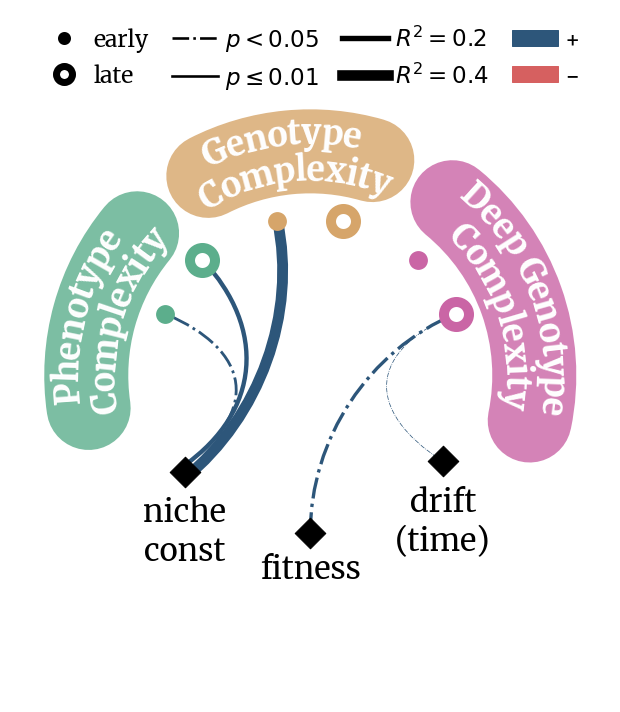

In [9]:
tp.tee(
    draw_plot,
    df,
    teeplot_subdir=teeplot_subdir,
)
